# EDA — Brazilian Federal Highway Accidents (2017–2023)

This notebook prepares the dataset for severity classification.
The work follows a single pass: load, clean, single-variable analysis, multi-variable analysis, feature engineering and finishes with the cleaned dataframe ready for modelling.

**Research questions**

1. How well do standard multiclass classification models predict traffic accident severity?
2. How does handling class imbalance affect the performance of these models, and how do the main methods of class imbalance handling compare?
3. Which features are most important in predicting traffic accident severity?

---
## 1 · Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

# --- Plot theme ---
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize':   (10, 5),
    'figure.dpi':       100,
    'axes.titleweight': 'bold',
    'axes.titlesize':   13,
    'axes.titlepad':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':        11,
})

# --- Palette ---
PALETTE = {
    'primary':  '#2E86AB',   # blue   — neutral / counts
    'accent':   '#E07A5F',   # coral  — highlight
    'danger':   '#C73E1D',   # red    — fatal / severe
    'warn':     '#F2A65A',   # amber  — injured
    'ok':       '#6BAA75',   # green  — without victims
    'muted':    '#9CA0A8',   # grey   — context
}
SEVERITY_COLORS = [PALETTE['ok'], PALETTE['warn'], PALETTE['danger']]

In [4]:
df = pd.read_csv('accidents_2017_to_2023_english.csv')
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded 463,152 rows × 27 columns


---
## 2 · First look

Shape, types, and head

In [5]:
print("Shape :", df.shape, "\n")
print("Dtypes:")
print(df.dtypes.to_string())
print()
df.head()

Shape : (463152, 27) 

Dtypes:
inverse_data              str
week_day                  str
hour                      str
state                     str
road_id               float64
km                        str
city                      str
cause_of_accident         str
type_of_accident          str
victims_condition         str
weather_timestamp         str
road_direction            str
wheather_condition        str
road_type                 str
road_delineation          str
people                  int64
deaths                  int64
slightly_injured        int64
severely_injured        int64
uninjured               int64
ignored                 int64
total_injured           int64
vehicles_involved       int64
latitude              float64
longitude             float64
regional                  str
police_station            str



,inverse_data,week_day,hour,state,road_id,km,city,cause_of_accident,type_of_accident,victims_condition,weather_timestamp,road_direction,wheather_condition,road_type,road_delineation,people,deaths,slightly_injured,severely_injured,uninjured,ignored,total_injured,vehicles_involved,latitude,longitude,regional,police_station
0,2017-01-01,sunday,01:45:00,RS,116.000,"34,9",VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.507,-50.941,SPRF-RS,DEL05-RS
1,2017-01-01,sunday,01:00:00,PR,376.000,636,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.754,-49.127,SPRF-PR,DEL01-PR
2,2017-01-01,sunday,04:40:00,BA,101.000,65,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.962,-38.095,SPRF-BA,DEL01-BA
3,2017-01-01,sunday,06:30:00,PA,316.000,"72,5",CASTANHAL,Driver's lack of attention to conveyance,Side impact collision,With dead victims,Sunrise,Decreasing,Clear sky,Simple,Straight,4,1,0,0,3,0,0,3,-1.290,-47.835,SPRF-PA,DEL01-PA
4,2017-01-01,sunday,09:00:00,GO,20.000,"220,5",POSSE,Road's defect,Collision with fixed object,With injured victims,Day,Decreasing,Clear sky,Simple,Temporary Detour,3,0,2,1,0,0,3,1,-14.142,-46.323,SPRF-DF,DEL02-DF


---
## 3 · Rename columns

The original names are inconsistent (mixed case, typos like `wheather_condition`).

In [6]:
df = df.rename(columns={
    'inverse_data':       'Date',
    'week_day':           'Day',
    'hour':               'Hour',
    'state':              'State',
    'road_id':            'Road_ID',
    'km':                 'Road_Km',
    'city':               'City',
    'cause_of_accident':  'Accident_Cause',
    'type_of_accident':   'Accident_Type',
    'victims_condition':  'Victims_Condition',
    'weather_timestamp':  'Day_Phase',
    'road_direction':     'Km_Direction',
    'wheather_condition': 'Weather_Condition',
    'road_type':          'Road_Type',
    'road_delineation':   'Road_Delineation',
    'people':             'People',
    'deaths':             'Deaths',
    'slightly_injured':   'Slightly_Injured',
    'severely_injured':   'Severely_Injured',
    'uninjured':          'Uninjured',
    'ignored':            'Ignored',
    'total_injured':      'Total_Injured',
    'vehicles_involved':  'Vehicles_Involved',
    'latitude':           'Latitude',
    'longitude':          'Longitude',
    'regional':           'Regional',
    'police_station':     'Police_Station',
})

df.head(3)

,Date,Day,Hour,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station
0,2017-01-01,sunday,01:45:00,RS,116.000,"34,9",VACARIA,Mechanical loss/defect of vehicle,Rear-end collision,With injured victims,Night,Decreasing,Clear sky,Simple,Straight,6,0,4,0,2,0,4,2,-28.507,-50.941,SPRF-RS,DEL05-RS
1,2017-01-01,sunday,01:00:00,PR,376.000,636,TIJUCAS DO SUL,Incompatible velocity,Run-off-road,With dead victims,Night,Increasing,Drizzle,Double,Curve,2,1,0,0,1,0,0,2,-25.754,-49.127,SPRF-PR,DEL01-PR
2,2017-01-01,sunday,04:40:00,BA,101.000,65,ENTRE RIOS,Driver was sleeping,Head-on collision,With dead victims,Sunrise,Decreasing,Cloudy,Simple,Curve,5,1,1,1,2,0,2,2,-11.962,-38.095,SPRF-BA,DEL01-BA


---
## 4 · Datetime & numeric conversions

Two cleanups, done together:

* `Date` + `Hour` => a single `Datetime` column (the originals are dropped).
* `Road_Km` uses European decimals — replace the comma so pandas sees a number.

In [7]:
# Combine Date + Hour, then drop the originals
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Hour'].astype(str))
df = df.drop(columns=['Date', 'Hour'])

# Move Datetime to the front for readability
df = df[['Datetime'] + [c for c in df.columns if c != 'Datetime']]

# Convert Road_Km (handling European decimal format)
df['Road_Km'] = pd.to_numeric(df['Road_Km'].str.replace(',', '.'), errors='coerce')

print(f"Datetime range: {df['Datetime'].min()}  =>  {df['Datetime'].max()}")
print(f"Road_Km dtype : {df['Road_Km'].dtype}")

Datetime range: 2017-01-01 00:00:00  =>  2023-08-31 23:59:00
Road_Km dtype : float64


---
## 5 · Missing values

Three columns hold all of the missingness. Each gets a treatment that fits its meaning:

| Column | Strategy | Rationale |
|---|---|---|
| `Regional` | drop the rows | very few rows, can't be filled |
| `Police_Station` | fill with `"UNKNOWN"` | usable categorical placeholder |
| `Road_ID` / `Road_Km` | sentinel + flag column | the *fact that road info is missing* is itself a feature |

In [8]:
print("Nulls before treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

Nulls before treatment:
Road_ID            990
Road_Km            990
Regional            10
Police_Station    1310


In [9]:
# 1) Drop rows missing Regional (very few)
df = df.dropna(subset=['Regional'])

# 2) Police_Station — fill with placeholder
df['Police_Station'] = df['Police_Station'].fillna('UNKNOWN')

# 3) Road_ID / Road_Km — flag + sentinel fill
df['Missing_Road_Data'] = df['Road_ID'].isna()
df['Road_ID']  = df['Road_ID'].fillna('NO_ROAD')
df['Road_Km']  = df['Road_Km'].fillna(-1)

remaining = df.isnull().sum().sum()
print(f"Remaining nulls: {remaining}")

Remaining nulls: 0


---
## 6 · Duplicate rows

Per supervisor feedback, exact duplicates will be dropped.

In [10]:
dups = df.duplicated().sum()
print(f"Exact duplicate rows: {dups}")

if dups:
    display(df[df.duplicated(keep=False)])

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {before - len(df)} rows  =>  {len(df):,} remaining")

Exact duplicate rows: 9


,Datetime,Day,State,Road_ID,Road_Km,City,Accident_Cause,Accident_Type,Victims_Condition,Day_Phase,Km_Direction,Weather_Condition,Road_Type,Road_Delineation,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude,Regional,Police_Station,Missing_Road_Data
19243,2017-10-20 14:25:00,friday,SC,282.000,483.900,FAXINAL DOS GUEDES,Disrespect of safe distance from the next car,Rear-end collision,Without victims,Day,Increasing,Sunny,Simple,Not Reported,2,0,0,0,2,0,0,2,-26.857,-52.246,SPRF-SC,DEL07-SC,False
75470,2017-10-20 14:25:00,friday,SC,282.000,483.900,FAXINAL DOS GUEDES,Disrespect of safe distance from the next car,Rear-end collision,Without victims,Day,Increasing,Sunny,Simple,Not Reported,2,0,0,0,2,0,0,2,-26.857,-52.246,SPRF-SC,DEL07-SC,False
79108,2017-11-11 17:00:00,saturday,GO,60.000,201.800,GUAPO,Slippery track,Collision with fixed object,Without victims,Day,Decreasing,Rainy,Double,Curve,1,0,0,0,1,0,0,1,-16.886,-49.623,SPRF-GO,DEL01-GO,False
79109,2017-11-11 17:00:00,saturday,GO,60.000,201.800,GUAPO,Slippery track,Collision with fixed object,Without victims,Day,Decreasing,Rainy,Double,Curve,1,0,0,0,1,0,0,1,-16.886,-49.623,SPRF-GO,DEL01-GO,False
80504,2017-11-19 15:40:00,sunday,RJ,40.000,113.000,DUQUE DE CAXIAS,Road's defect,Rear-end collision,With injured victims,Day,Decreasing,Rainy,Multiple,Not Reported,3,0,1,0,2,0,1,2,-22.719,-43.290,SPRF-RJ,DEL01-RJ,False
80505,2017-11-19 15:40:00,sunday,RJ,40.000,113.000,DUQUE DE CAXIAS,Road's defect,Rear-end collision,With injured victims,Day,Decreasing,Rainy,Multiple,Not Reported,3,0,1,0,2,0,1,2,-22.719,-43.290,SPRF-RJ,DEL01-RJ,False
353536,2021-12-16 17:30:00,thursday,SC,101.000,135.300,BALNEARIO CAMBORIU,Acessing the road without seeing the presence ...,Head-on collision,With injured victims,Day,Increasing,Clear sky,Simple,Intersection,2,0,1,0,1,0,1,2,-27.005,-48.627,SPRF-SC,DEL04-SC,False
354092,2021-12-16 17:30:00,thursday,SC,101.000,135.300,BALNEARIO CAMBORIU,Acessing the road without seeing the presence ...,Head-on collision,With injured victims,Day,Increasing,Clear sky,Simple,Intersection,2,0,1,0,1,0,1,2,-27.005,-48.627,SPRF-SC,DEL04-SC,False
381910,2022-03-30 20:19:00,wednesday,GO,50.000,263.500,CATALAO,Driver's lack of reaction,Overturn,With injured victims,Night,Increasing,Clear sky,Double,Temporary Detour,1,0,1,0,0,0,1,1,-18.052,-47.863,SPRF-GO,DEL06-GO,False
381911,2022-03-30 20:19:00,wednesday,GO,50.000,263.500,CATALAO,Driver's lack of reaction,Overturn,With injured victims,Night,Increasing,Clear sky,Double,Temporary Detour,1,0,1,0,0,0,1,1,-18.052,-47.863,SPRF-GO,DEL06-GO,False



Dropped 9 rows  =>  463,133 remaining


---
## 7 · Summary statistics

In [11]:
df.describe(include='number')

,Road_Km,People,Deaths,Slightly_Injured,Severely_Injured,Uninjured,Ignored,Total_Injured,Vehicles_Involved,Latitude,Longitude
count,"463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000","463,133.000"
mean,260.834,2.362,0.079,0.835,0.260,1.044,0.144,1.095,1.646,"-2,343.382","-8,925.341"
std,227.535,1.925,0.332,1.075,0.603,1.502,0.438,1.205,0.731,"1,519,144.253","5,903,163.966"
min,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,"-1,033,383,000.000","-4,016,764,000.000"
25%,77.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-25.331,-50.303
50%,195.000,2.000,0.000,1.000,0.000,1.000,0.000,1.000,2.000,-20.420,-47.808
75%,410.000,3.000,0.000,1.000,0.000,1.000,0.000,1.000,2.000,-12.827,-42.642
max,"1,454.500",80.000,21.000,61.000,31.000,73.000,54.000,66.000,23.000,163.000,717.000


---
## 8 · Univariate analysis

### 8.1 · Deaths per accident (Enhanced)

Most accidents have zero fatalities.

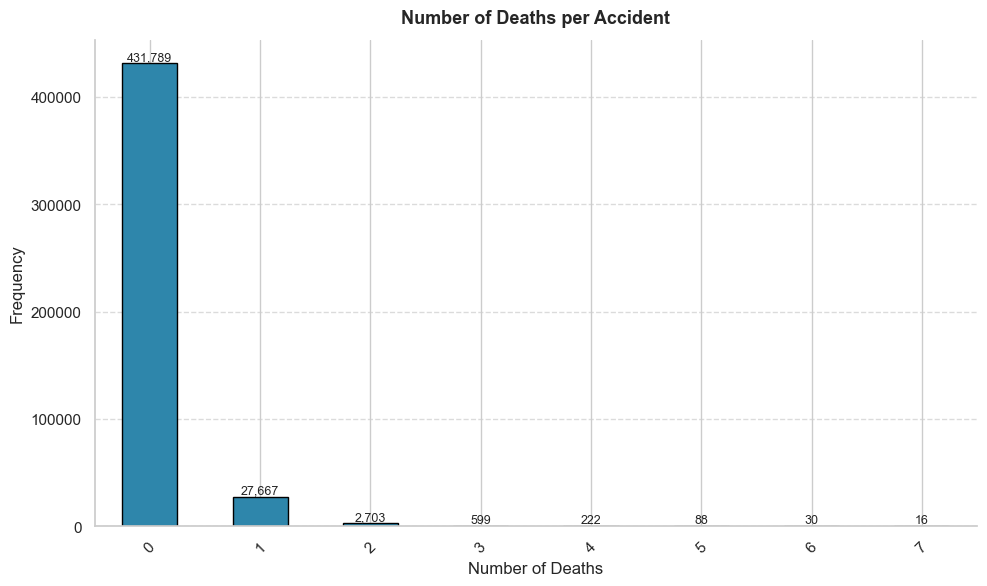

In [23]:
# Plot
plt.figure(figsize=(10, 6))
deaths_top = df['Deaths'].value_counts().sort_index().head(8)
bars = deaths_top.plot(kind='bar', color=PALETTE['primary'], edgecolor='black')

# Labels and title
plt.xlabel('Number of Deaths')
plt.ylabel('Frequency')
plt.title('Number of Deaths per Accident')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, (bar, v) in enumerate(zip(bars.patches, deaths_top.values)):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:,}',
             ha='center', va='bottom', fontsize=9)

# Show the plot
plt.tight_layout()
plt.show()

### 8.2 · `Ignored` distribution (Enhanced)

`Ignored` records people whose condition was not reported. Roughly 12% of accidents have at least one ignored person.

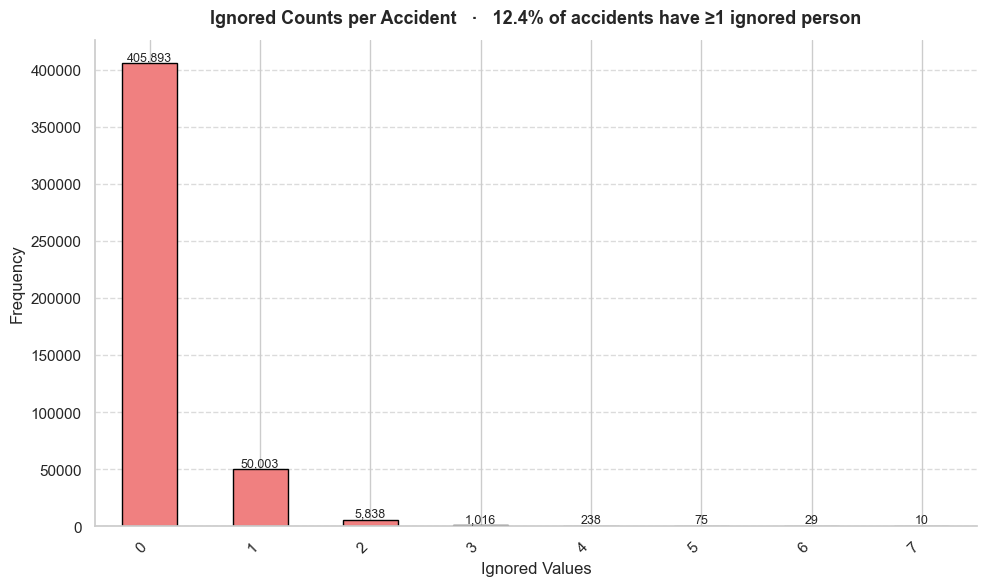

'12.4% of accidents have at least 1 ignored person'

In [28]:

# Calculate statistics
share = (df['Ignored'] > 0).mean()

# Plot
plt.figure(figsize=(10, 6))
ignored_top = df['Ignored'].value_counts().sort_index().head(8)
ignored_top.plot(kind='bar', color='lightcoral', edgecolor='black')

# Labels and title
plt.xlabel('Ignored Values')
plt.ylabel('Frequency')
plt.title(f'Ignored Counts per Accident   ·   {share:.1%} of accidents have ≥1 ignored person')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
bars = plt.gca()
for i, (bar, v) in enumerate(zip(bars.patches, ignored_top.values)):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:,}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Display the proportion
display(f"{share:.1%} of accidents have at least 1 ignored person")

### 8.3 · Logical checks

Two consistency checks:

* `Total_Injured` should equal `Slightly_Injured + Severely_Injured`.
* `People` should be ≥ `Vehicles_Involved`.

In [16]:
mismatch_total   = (df['Total_Injured'] != df['Slightly_Injured'] + df['Severely_Injured']).sum()
mismatch_people  = (df['People'] < df['Vehicles_Involved']).sum()

print(f"Total_Injured ≠ Slight + Severe : {mismatch_total}")
print(f"People < Vehicles_Involved      : {mismatch_people}")

if mismatch_total == 0 and mismatch_people == 0:
    print("\n Both checks pass => count columns are internally consistent.")

Total_Injured ≠ Slight + Severe : 0
People < Vehicles_Involved      : 0

 Both checks pass => count columns are internally consistent.


### 8.4 · Accident cause — raw distribution

The dataset uses 80+ free-text labels with a heavy long tail. Per supervisor feedback: **what is cause #1?**

In [17]:
cause_counts = df['Accident_Cause'].value_counts()
cause_share  = df['Accident_Cause'].value_counts(normalize=True)

print(f"Unique cause labels       : {df['Accident_Cause'].nunique()}")
print(f"#1 cause                  : {cause_counts.index[0]!r}")
print(f"   covers                 : {cause_share.iloc[0]:.1%} of all accidents")
print(f"Top 10 causes together    : {cause_share.head(10).sum():.1%}")

Unique cause labels       : 85
#1 cause                  : "Driver's lack of attention to conveyance"
   covers                 : 23.3% of all accidents
Top 10 causes together    : 69.5%


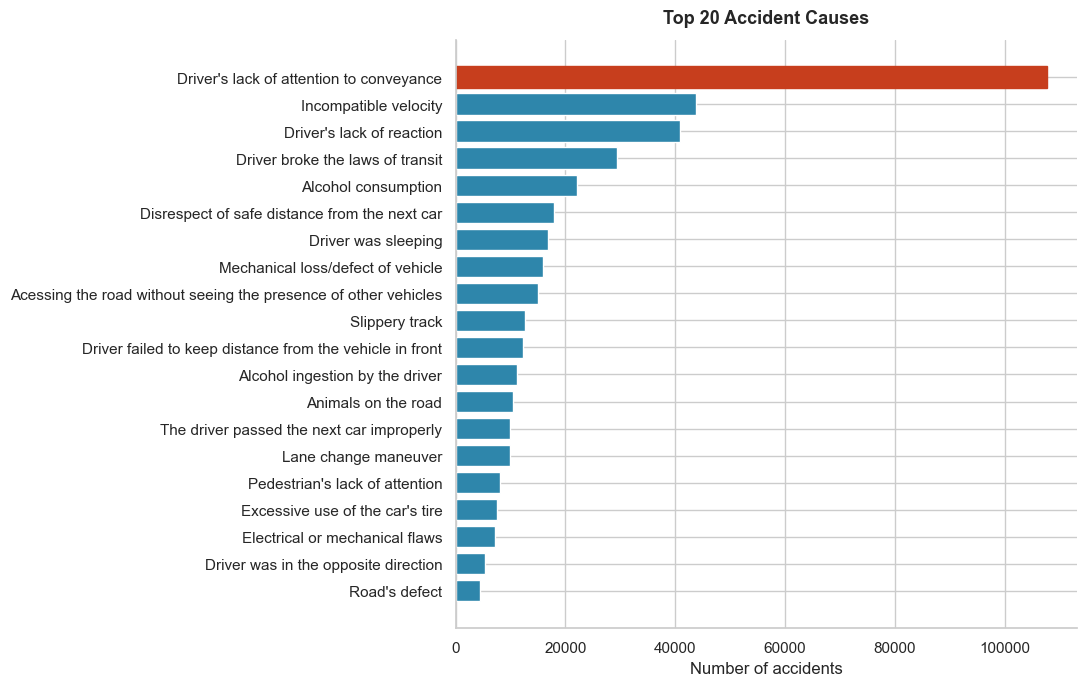

In [29]:
top20 = cause_counts.head(20)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20.index, top20.values,
               color=PALETTE['primary'], edgecolor='white')
bars[0].set_color(PALETTE['danger'])     # highlight #1
ax.invert_yaxis()
ax.set(title='Top 20 Accident Causes', xlabel='Number of accidents', ylabel='')
plt.tight_layout(); plt.show()

**Findings:** *Driver's lack of attention to conveyance* dominates. Top 10 causes cover the large majority of the dataset, therefore the next step will be to try grouping them.

### 8.5 · Combining similar causes

There are more than 80 raw tags, which isn't adequate for this model. I'm trying to group them into broader categories by comparing substrings (to capture renamed tags or nearly duplicate tags as well).

In [32]:
print(df['Accident_Cause'].value_counts().to_string())

Accident_Cause
Driver's lack of attention to conveyance                           107788
Incompatible velocity                                               43722
Driver's lack of reaction                                           40883
Driver broke the laws of transit                                    29318
Alcohol consumption                                                 22140
Disrespect of safe distance from the next car                       17929
Driver was sleeping                                                 16820
Mechanical loss/defect of vehicle                                   15850
Acessing the road without seeing the presence of other vehicles     14973
Slippery track                                                      12648
Driver failed to keep distance from the vehicle in front            12262
Alcohol ingestion by the driver                                     11229
Animals on the road                                                 10533
The driver passed the n

In [33]:
def categorise_cause(c: str) -> str:
    """Map a raw accident-cause string to a broader category."""
    if not isinstance(c, str):
        return 'Unknown'
    s = c.lower()
    # alcohol & drugs first — they often appear inside other phrases
    if 'alcohol' in s or 'drug' in s:                          return 'Alcohol / Drugs'
    if 'pedestrian' in s:                                       return 'Pedestrian-related'
    if any(k in s for k in ['sleeping', 'cardiac', 'mental',
                             'cellphone']):                     return 'Driver state (fatigue / medical / distraction)'
    if any(k in s for k in ['velocity', 'distance', 'brake']):  return 'Speed & following distance'
    if any(k in s for k in ['mechanical', 'tire', 'electrical',
                             'suspension', 'headlight',
                             'sinalization/ilumination',
                             'load', 'cargo', 'modification']): return 'Vehicle defect'
    if any(k in s for k in ['slippery','pavement','pothole','holes',
                             'sand','wreckage','oil','water','drainage',
                             'drenage','curvy','downhill','unlevel',
                             'breakdown lane','obstacle','maintenance',
                             'speed reducer','static object',
                             "road's defect","flaws/problems in the road"]):
        return 'Road condition / infrastructure'
    if any(k in s for k in ['sinalization','ilumination of the road',
                             'visibility','fog','smoke','sign post',
                             'traffic light']):                  return 'Visibility & signage'
    if 'rain' in s or 'natural phenomena' in s:                  return 'Weather'
    if 'animal' in s:                                            return 'Animals'
    if any(k in s for k in ['lack of attention','lack of reaction',
                             'broke the laws','opposite direction',
                             'lane change','passed the next car',
                             'acessing the road','intersection',
                             'conversion','red traffic light','illegally',
                             'breakdown lane','irregular access',
                             'prohibited place','drifting',
                             'temporary return','on sidewalk']):
        return 'Driver behaviour'
    return 'Other'

df['Cause_Group'] = df['Accident_Cause'].apply(categorise_cause)
df['Cause_Group'].value_counts(normalize=True).mul(100).round(1)

Cause_Group
Driver behaviour                                 49.200
Speed & following distance                       16.400
Alcohol / Drugs                                   7.800
Vehicle defect                                    7.500
Road condition / infrastructure                   6.200
Driver state (fatigue / medical / distraction)    4.700
Pedestrian-related                                3.100
Animals                                           2.300
Visibility & signage                              1.200
Weather                                           1.000
Other                                             0.800
Name: proportion, dtype: float64

**Finding.** *Driver behaviour* (inattention, illegal manoeuvres, ignored signs) is dominant, followed by *Speed & following distance* and *Alcohol / Drugs*. Environmental factors (weather, animals, visibility) are responsible for a much smaller accidents.

### 8.6 · Contextual categorical columns


### 8.7 · Time distribution

Derive time features once, then chart them. `Is_Weekend` is also derived here.

### 8.8 · Working days vs Saturday / Sunday

Per supervisor feedback, compare working days (Mon–Fri) against the weekend (Sat–Sun)

### 8.9 · Victims condition  (target variable)

---
## 9 · Bivariate / multivariate analysis

### 9.1 · Weather and day-phase context

### 9.2 · Correlation — vehicles, injuries, deaths

### 9.3 · Road type × road delineation

### 9.4 · Severity by State and Regional district

Three views, per supervisor feedback:

1. Average deaths per accident by State.
2. Severity-class mix (no-victims / injured / dead) by State.
3. Same severity mix by federal-police `Regional` district.

### 9.5 · Map of fatal accidents

### 9.6 · Which causes produce the deadliest accidents?

### 9.7 · `Ignored` field exploration

---
## 10 · Outliers

IQR-based outlier counts for each numeric column, plus a coordinate check.